# 05 — Sampling: turning probabilities into text

A trained model gives us, at each step, a probability distribution over the next token. Turning
that distribution into actual text is **decoding**, and the strategy you pick changes the output
character completely — from robotic repetition to incoherent randomness, with the good stuff in
between. We implement all four from scratch and *look at what each does to the distribution*:

- **Greedy** — always take the most likely token.
- **Temperature** — sharpen or flatten the distribution before sampling.
- **Top-k** — sample only from the k most likely tokens.
- **Top-p (nucleus)** — sample from the smallest set whose probability mass exceeds p.

All four live in one place — `GPT.generate` in [`model.py`](../model.py). Here we pull the logic
apart and visualize it.

In [1]:
import sys, math
from pathlib import Path
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from model import GPT

ROOT = Path("..").resolve()
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")

ckpt = torch.load(ROOT/"checkpoints"/"shakespeare_char.pt", map_location=device, weights_only=False)
model = GPT(ckpt["config"]).to(device); model.load_state_dict(ckpt["model"]); model.eval()
meta = ckpt["meta"]
encode = lambda s: [meta["stoi"][c] for c in s]
decode = lambda ids: "".join(meta["itos"][i] for i in ids)
print(f"loaded model: {model.num_params()/1e6:.2f}M params, val loss {ckpt['val_loss']:.3f}")

loaded model: 0.80M params, val loss 1.609


## The distribution we're sampling from

Let's ground everything in one concrete step. We feed the prompt `"To be, or not to b"` and look
at what the model thinks comes next. (It should be very sure it's `"e"`.) Every strategy below is
just a different way of collapsing this distribution into one choice.

In [2]:
prompt = "To be, or not to b"
ids = torch.tensor([encode(prompt)], device=device)
with torch.no_grad():
    logits, _ = model(ids)            # (1, 1, vocab) -- logits for the next token
logits = logits[0, -1]                # (vocab,)
probs = F.softmax(logits, dim=-1)

topk = torch.topk(probs, 10)
print(f"prompt: {prompt!r}\ntop-10 next-character candidates:")
for p, i in zip(topk.values.tolist(), topk.indices.tolist()):
    bar = "#" * int(p * 50)
    print(f"  {meta['itos'][i]!r:6s} {p:6.3f}  {bar}")

prompt: 'To be, or not to b'
top-10 next-character candidates:
  'e'     0.762  ######################################
  'r'     0.048  ##
  'a'     0.041  ##
  'l'     0.039  #
  'o'     0.035  #
  'u'     0.026  #
  'y'     0.025  #
  'i'     0.022  #
  'h'     0.000  
  'E'     0.000  


## 1. Greedy decoding

Take the argmax every step. **Deterministic** — same prompt always yields the same continuation.
Its failure mode is that always-most-likely quickly falls into **loops**: the highest-probability
token given "I am the" might be "king", and given "the king" might be "of", and it circles back.
Greedy is `temperature = 0` in our `generate`.

In [3]:
def show(strategy, **kw):
    torch.manual_seed(0)
    start = torch.tensor([encode("\n")], device=device)
    out = model.generate(start, max_new_tokens=300, use_cache=True, **kw)
    print(f"=== {strategy} ===")
    print(decode(out[0].tolist()).strip())
    print()

show("greedy (temperature=0)", temperature=0.0)

=== greedy (temperature=0) ===
Second Servingman:
The shall be the comes of the world of the world.

KING RICHARD III:
What the shall be the comes of the world of the world.

KING RICHARD III:
What thou hast the stand of the comple of the words
That the stand of the company of the world of the worse
That the ware t the worn the



Notice greedy tends to produce clean but repetitive text and often gets stuck on a common phrase.
For deterministic *tasks* (translation, code) greedy or beam search is fine; for *creative* text
we want variety, which means **sampling** — and the next three knobs control how adventurous that
sampling is.

## 2. Temperature

Before softmax, divide the logits by a **temperature** T:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

- **T < 1** sharpens — amplifies the gap between logits, so the top tokens get even more mass.
  The limit T→0 is greedy. Output: safer, more repetitive.
- **T > 1** flattens — shrinks the gaps, spreading mass toward rare tokens. Output: more diverse,
  eventually incoherent.
- **T = 1** is the model's own distribution, unchanged.

Let's *see* it reshape the exact distribution from above.

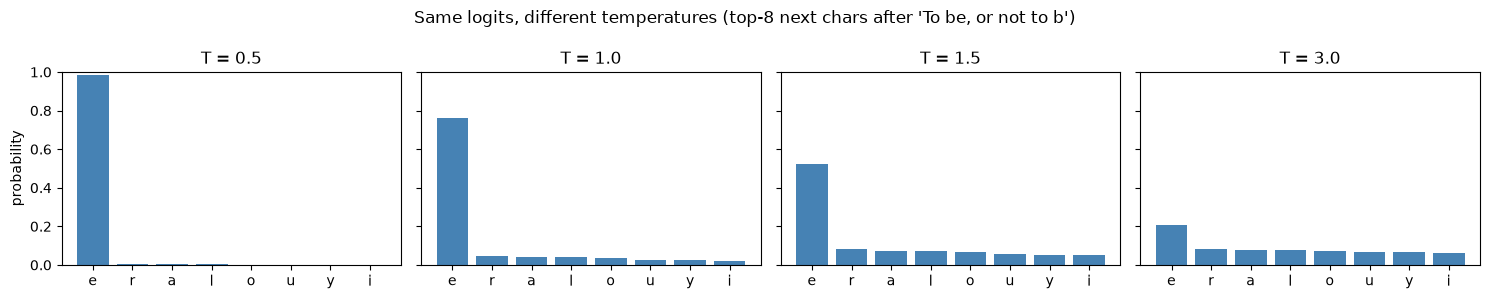

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3), sharey=True)
for ax, T in zip(axes, [0.5, 1.0, 1.5, 3.0]):
    p = F.softmax(logits / T, dim=-1)
    tk = torch.topk(p, 8)
    ax.bar([meta["itos"][i] for i in tk.indices.tolist()], tk.values.tolist(),
           color="steelblue")
    ax.set_title(f"T = {T}"); ax.set_ylim(0, 1)
axes[0].set_ylabel("probability")
fig.suptitle("Same logits, different temperatures (top-8 next chars after 'To be, or not to b')")
plt.tight_layout(); plt.show()

In [5]:
for T in [0.5, 0.8, 1.2]:
    show(f"temperature = {T}", temperature=T)

=== temperature = 0.5 ===
When he look your the hand a day and so present,
And hear shall be some in my soul do a slate
That we come the country of his life his hands,
That his shall before the will stands have have will him;
The shall have contry in as to my mine.

SICINIUS:
I am it be the comenty for mean?


Must So willll



=== temperature = 0.8 ===
When he? I am good heaven was are not see warl;
And the rest thy best and highness the ground
That we can eyes not one of her life his hands
To would confession bound the was grace a cannot part,
This true in this execution, as good a with his graw chaste
Thou very frest orceeived tut o so

But bet



=== temperature = 1.2 ===
Will not comman with i' to a darbine
As purpose to fronded father, sir? is.

AUFIDIUS:
O, caius roposice, eyes not our powen
Aliquaries.
Children: his child, gAlbours you nament duke unhamer,
Tourd latter nink him. What suiciase: for men.

LEONTES:
I know it?

HORRTEMELIO:
I do's be thou know oullld



Low temperature reads as cautious and a bit repetitive; high temperature invents words and loses
the thread. **~0.8 is the usual sweet spot** for this kind of model — enough variety to avoid
loops, enough discipline to stay coherent.

## 3. Top-k sampling

Temperature alone has a flaw: even at moderate T, the long tail of *thousands* of low-probability
tokens collectively holds real mass, so occasionally you sample genuine garbage. **Top-k** fixes
this bluntly: keep only the **k highest-probability tokens**, set the rest to −∞, renormalize,
sample. The tail can never be chosen.

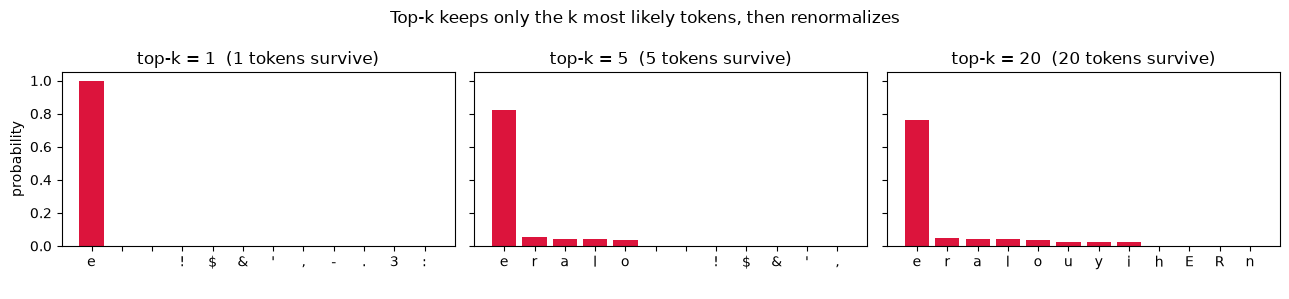

In [6]:
def topk_filter(logits, k):
    v = torch.topk(logits, k).values          # the k largest logits
    out = logits.clone()
    out[out < v[-1]] = float("-inf")          # kill everything below the k-th
    return out

fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, k in zip(axes, [1, 5, 20]):
    p = F.softmax(topk_filter(logits, k), dim=-1)
    tk = torch.topk(p, 12)
    colors = ["crimson" if v > 0 else "lightgray" for v in tk.values.tolist()]
    ax.bar(range(12), tk.values.tolist(), color=colors)
    ax.set_xticks(range(12)); ax.set_xticklabels([meta["itos"][i] for i in tk.indices.tolist()])
    ax.set_title(f"top-k = {k}  ({(p>0).sum().item()} tokens survive)")
axes[0].set_ylabel("probability")
fig.suptitle("Top-k keeps only the k most likely tokens, then renormalizes")
plt.tight_layout(); plt.show()

In [7]:
for k in [5, 40]:
    show(f"temperature=0.8, top_k={k}", temperature=0.8, top_k=k)

=== temperature=0.8, top_k=5 ===
When he traitor of him and a stround
As in his house have shall tends and highness the would
That would they hand of my heaven of shievion,
And would their true is and with his cause may for her,
This happy time to be thy hands to more.

CORIOLANUS:
I say it?

Serversesenge:
How in the she wount his



=== temperature=0.8, top_k=40 ===
When he? I am good heaven was are not see warl;
And the rest thy best and highness the ground
That we can eyes not one of her life his hands
To would confession bound the was grace a cannot part,
This true in this execution, as good a with his graw chaste
Thou very frest orceeived tut o so

But bet



Top-k with k≈40 and T≈0.8 is a robust, popular default. Its one weakness: **k is fixed** but the
right cutoff isn't. When the model is very confident (only 2–3 tokens are plausible), a fixed k=40
still admits 37 implausible ones. When it's genuinely uncertain (many tokens plausible), k=40 may
be too *few*. That mismatch motivates the last method.

## 4. Top-p (nucleus) sampling

Instead of a fixed *count*, fix a **probability mass** p. Sort tokens by probability, walk down
accumulating mass, and keep the smallest set whose cumulative probability first reaches p (say
0.9); sample from those. The candidate set **grows and shrinks automatically** with the model's
confidence — small when it's sure, large when it's not. This is the default in most production
LLM APIs.

The one implementation subtlety: after sorting and cumulative-summing, we must **keep the token
that crosses the threshold** (the shift below), otherwise a single token with probability > p
would leave nothing to sample.

In [8]:
def topp_filter(logits, p):
    s_logits, s_idx = torch.sort(logits, descending=True)
    cum = torch.cumsum(F.softmax(s_logits, dim=-1), dim=-1)
    remove = cum - F.softmax(s_logits, dim=-1) > p     # shift right: keep the crossing token
    s_logits[remove] = float("-inf")
    return torch.full_like(logits, float("-inf")).scatter(0, s_idx, s_logits)

# how many tokens survive at each p, for THIS (confident) distribution vs a flatter one
for label, lg in [("confident step ('...to b')", logits),
                  ("flatter step (T=2.5)",       logits / 2.5)]:
    sizes = [(F.softmax(topp_filter(lg, pp), dim=-1) > 0).sum().item() for pp in [0.5, 0.9, 0.95]]
    print(f"{label:28s}  nucleus size at p=0.5/0.9/0.95: {sizes}")
print("\n-> same p adapts: the confident step keeps very few tokens, the flat step keeps more")

confident step ('...to b')    nucleus size at p=0.5/0.9/0.95: [1, 5, 6]
flatter step (T=2.5)          nucleus size at p=0.5/0.9/0.95: [4, 20, 33]

-> same p adapts: the confident step keeps very few tokens, the flat step keeps more


In [9]:
for p in [0.9, 0.95]:
    show(f"temperature=0.8, top_p={p}", temperature=0.8, top_p=p)

=== temperature=0.8, top_p=0.9 ===
When he look of with all our death, but you have said
To shall you some in my abound of your death.

First Murderer:
What I have not children be our stands,
And I will him service hath hath will be in the sink
To see the fice so of the day;
Where with same hold way the now falll d the are thouse hit



=== temperature=0.8, top_p=0.95 ===
When he look you, then your starring
As present to be not shall be some in change.

First Servingman:
As a hand for you compent we have a him beaund
As the such bounds with his as hath handed well
That shall in the call suitions of their for here,
Which meet wake your servictory in the loong to be
T



## Side-by-side summary

| strategy | determinism | diversity | typical use |
|---|---|---|---|
| **greedy** (T=0) | deterministic | none — loops | tasks with one right answer; debugging |
| **temperature** | random | knob: low=safe, high=wild | the base randomness control |
| **top-k** | random | bounded by k | strong, simple default (k≈40) |
| **top-p** | random | adapts to confidence | production default (p≈0.9) |

In practice you **combine** them: temperature ≈ 0.8 to set overall randomness, then top-k *or*
top-p to clip the unreliable tail. That's exactly what `GPT.generate` exposes, and what our
`sample.py` CLI wraps:

```bash
python sample.py --ckpt checkpoints/shakespeare_char.pt --prompt "ROMEO:" \
    --temperature 0.8 --top_k 40 --max_new_tokens 400
```

## Takeaways

- Decoding turns a **distribution** into **text**; the strategy matters as much as the model for
  perceived quality.
- **Greedy** is deterministic and loop-prone. **Temperature** rescales logits to control
  randomness (T→0 = greedy, T>1 = wilder). **Top-k** truncates to a fixed number of candidates;
  **top-p** truncates to a fixed probability mass, adapting to the model's confidence.
- The practical recipe: **temperature ~0.8 + (top-k 40 or top-p 0.9)**.
- We implemented each as a small logit-filtering function; the visualizations show *exactly* how
  each one reshapes the next-token distribution.

**Interview quick-fire:**
- *Difference between top-k and top-p?* → top-k keeps a fixed *number* of tokens; top-p keeps a fixed *cumulative probability*, so the candidate set grows/shrinks with the model's certainty.
- *What does temperature do mechanically?* → divides logits before softmax; <1 sharpens, >1 flattens.
- *Why not always use greedy?* → it's deterministic and degenerates into repetition; creative generation needs sampling.

**Next:** [06 — Experiments](06_scaling_and_attention.ipynb): a mini scaling-law plot across
three model sizes, and attention-map visualizations that show what the heads actually learned.